## MAIN EDA

Each of us worked through this dataset separately first. **The preprocessing and cleaning — the
missing-value handling, the type fixes, the join logic, and the reasoning behind each of those
decisions — lives in our individual EDA notebooks**, not here:

- [`leomary_eda.ipynb`](leomary_eda.ipynb)
- [`amina_ukeda.ipynb`](amina_ukeda.ipynb)
- [`morris_eda.ipynb`](morris_eda.ipynb)

**This notebook is not a fourth cleaning pass.** It is where we collect the findings the group
found most interesting across all of that individual work — the ones that either surprised us,
changed how we plan to model the data, or came up independently in more than one of our
notebooks. The charts below are copied from the notebooks they came from.


In [56]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as stats 

---
## Sections 1–4 are Leomary Rodriguez's findings, from [`leomary_eda.ipynb`](leomary_eda.ipynb).*

In [57]:
from pathlib import Path

# The cleaned files produced by Section 6 of leomary_eda.ipynb.
# They are ~1.1 GB so they are not committed - see data/README.md.
CLEAN = Path('../data/preprocessed')

if not (CLEAN / 'accidents_clean.csv').exists():
    raise FileNotFoundError(
        "\nCleaned data not found in data/preprocessed/.\n"
        "These files are about 1.1 GB, so they are not committed to the repo.\n\n"
        "One-time setup:\n"
        "  1. Download both CSVs from\n"
        "     https://www.kaggle.com/datasets/tsiaras/uk-road-safety-accidents-and-vehicles\n"
        "  2. Put them in data/raw/\n"
        "  3. Run leomary_eda.ipynb Sections 1-6, which writes the cleaned files\n\n"
        "See data/README.md for detail.\n"
    )

accidents = pd.read_csv(CLEAN / 'accidents_clean.csv', low_memory=False)
vehicles  = pd.read_csv(CLEAN / 'vehicles_clean.csv', low_memory=False)

severity_order = ['Slight', 'Serious', 'Fatal']

# Findings 1 and 4 compare something from the vehicle file against severity,
# which lives in the accident file, so the two tables have to be joined first
vehicles_with_severity = vehicles.merge(
    accidents[['Accident_Index', 'Accident_Severity']],
    on='Accident_Index', how='inner')

print('accidents:', accidents.shape)
print('vehicles: ', vehicles.shape)
print('joined:   ', vehicles_with_severity.shape)


accidents: (2047256, 36)
vehicles:  (2177205, 24)
joined:    (2058408, 25)


---
## Section 1 — Vehicle Make

`Vehicle_Manoeuvre` told me what the vehicle was doing. The `make` column tells me what badge
was on the front, which is the question people usually want answered: are some brands involved
in worse crashes than others?

`make` is filled in for 94.9% of rows and has 535 distinct values, so I keep only the makes with
at least 10,000 rows in the joined table. First though, a plain count of vehicle types. It turns
out to be the thing I need in order to read the brand chart properly, and one of its entries is
odd enough to be worth chasing afterwards.

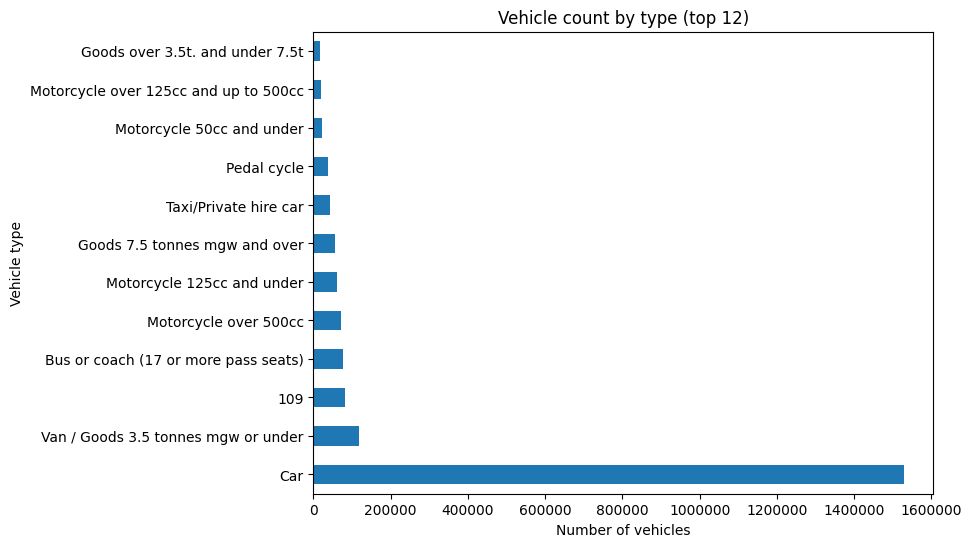

In [58]:
vehicles['Vehicle_Type'].value_counts().head(12).plot(kind='barh', figsize=(8, 6))
plt.title('Vehicle count by type (top 12)')
plt.xlabel('Number of vehicles')
plt.ylabel('Vehicle type')
# without this the axis reads 0.0 to 1.6 with a small '1e6' in the corner
plt.ticklabel_format(style='plain', axis='x')
plt.show()


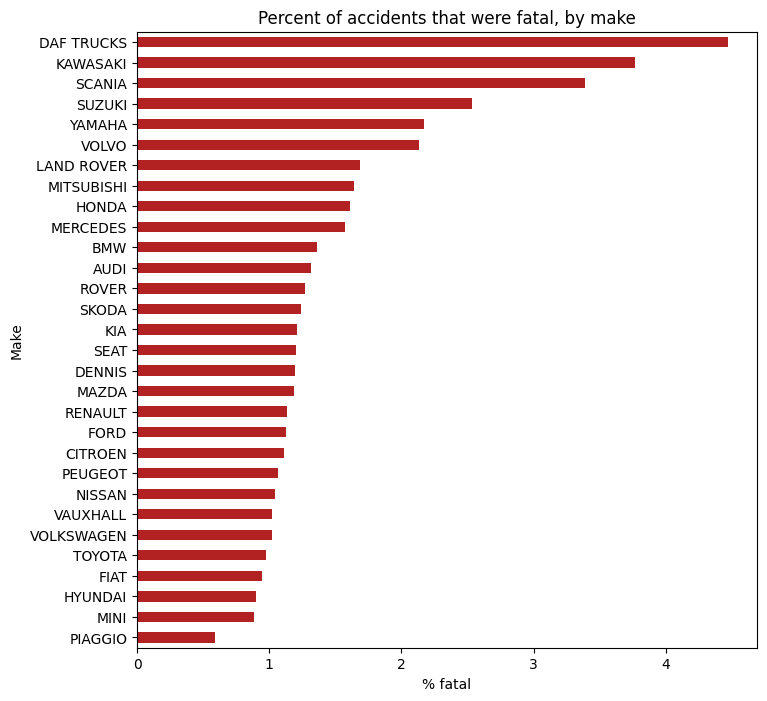

In [59]:
make_counts = vehicles_with_severity['make'].value_counts()
common_makes = make_counts[make_counts >= 10000].index

make_severity = vehicles_with_severity.groupby('make')['Accident_Severity'].value_counts(normalize=True).unstack()
fatal_by_make = (make_severity['Fatal'] * 100).loc[common_makes].sort_values()

fatal_by_make.plot(kind='barh', color='firebrick', figsize=(8, 8))
plt.title('Percent of accidents that were fatal, by make')
plt.xlabel('% fatal')
plt.ylabel('Make')
plt.show()


In [60]:
# The four makes at the top of that chart - what are they actually selling?
for name in ['DAF TRUCKS', 'KAWASAKI', 'SCANIA', 'SUZUKI', 'VOLVO']:
    mix = vehicles_with_severity.loc[vehicles_with_severity['make'] == name, 'Vehicle_Type']
    top3 = (mix.value_counts(normalize=True) * 100).head(3)
    print(name.ljust(11), ' | '.join(f'{k[:32]} {v:.0f}%' for k, v in top3.items()))


DAF TRUCKS  Goods 7.5 tonnes mgw and over 64% | Goods over 3.5t. and under 7.5t 18% | Van / Goods 3.5 tonnes mgw or un 6%
KAWASAKI    Motorcycle over 500cc 74% | Motorcycle over 125cc and up to  17% | Motorcycle 125cc and under 4%
SCANIA      Goods 7.5 tonnes mgw and over 49% | Bus or coach (17 or more pass se 40% | Goods over 3.5t. and under 7.5t 4%
SUZUKI      Car 43% | Motorcycle over 500cc 39% | Motorcycle over 125cc and up to  8%
VOLVO       Car 43% | Bus or coach (17 or more pass se 37% | Goods 7.5 tonnes mgw and over 16%


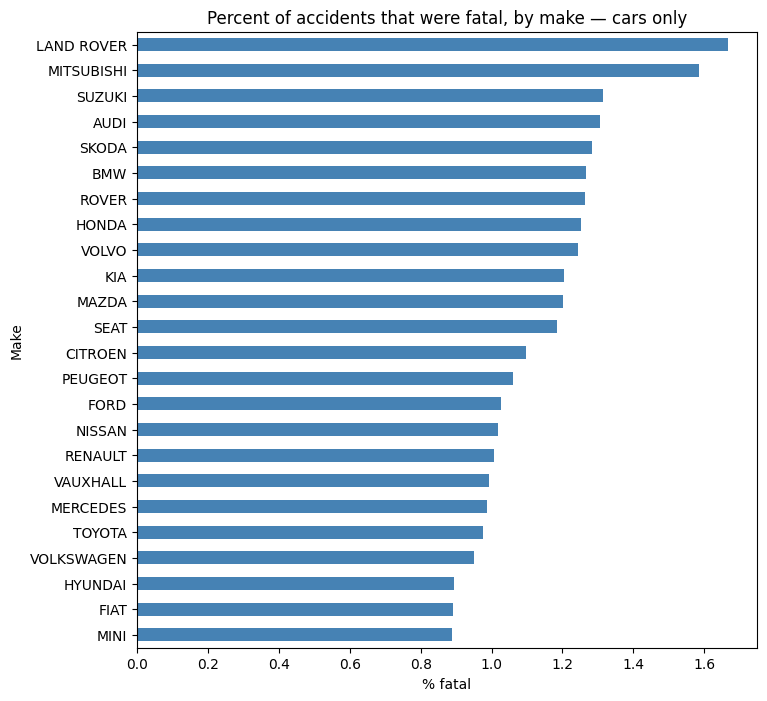

In [61]:
# Same chart, but comparing cars against cars only
cars = vehicles_with_severity[vehicles_with_severity['Vehicle_Type'] == 'Car']

car_make_counts = cars['make'].value_counts()
common_car_makes = car_make_counts[car_make_counts >= 10000].index

car_make_severity = cars.groupby('make')['Accident_Severity'].value_counts(normalize=True).unstack()
fatal_by_car_make = (car_make_severity['Fatal'] * 100).loc[common_car_makes].sort_values()

fatal_by_car_make.plot(kind='barh', color='steelblue', figsize=(8, 8))
plt.title('Percent of accidents that were fatal, by make — cars only')
plt.xlabel('% fatal')
plt.ylabel('Make')
plt.show()


### Finding 1: the brand ranking is mostly measuring what each brand builds

The first chart looks dramatic. **DAF Trucks is 4.47% fatal and Piaggio is 0.59%** — a
seven-and-a-half-fold spread between brands, which would be a striking thing to put on a
dashboard.

It is also almost entirely an illusion, and the top of the list gives it away. DAF builds
lorries, Scania builds lorries and coaches, and Kawasaki builds big motorcycles. These are not dangerous *brands*, they are
brands that happen to make the vehicle types Finding 4's warning applies to.

**Suzuki is the clearest tell.** It sits at 2.53% fatal, more than double Ford — but the mix
printout shows Suzuki is only 43% cars and 39% motorcycles over 500cc. Volvo does the same
thing from a different direction: 43% cars, 37% buses and 16% heavy goods. The badge is hiding
three completely different vehicles behind one label.

So I redrew it comparing **cars against cars**, which is the second chart. The spread collapses
from 7.6x down to **1.9x**. Suzuki falls from 2.53% to 1.31%, and Volvo from 2.13% to 1.24%.
Almost everything the first chart appeared to show about brands was vehicle type wearing a
badge.

What survives the control is small but not nothing, and it points somewhere familiar:

- **Land Rover 1.67% and Mitsubishi 1.59%** at the top — the 4x4s.
- **Mini 0.89%, Fiat 0.89% and Hyundai 0.89%** at the bottom — small city cars.
- Ford, Vauxhall, Renault and Nissan all sit within a whisker of the 1.08% car average.

That ordering looks much more like *where a car gets driven* than how safe it is. Big 4x4s do
disproportionately many miles on exactly the fast rural roads Findings 5 and 6 flagged, and
superminis do their miles in town. I think this is Finding 5 and Finding 6 showing up a third
time rather than anything about the vehicles themselves.

**This is not a safety rating and should not be presented as one.** Three reasons: a row is a
vehicle *involved in* a crash rather than a casualty, so a high number can mean the brand killed
someone in the other car; I have no idea how many miles any brand covers, which is the same
exposure problem as Finding 4; and I cannot separate the car from the person who chose it or the
roads they drive it on. `make` is also missing for 5.1% of rows overall and about a quarter of
2015, so the recent years are thinner than the rest.

For the model, the practical conclusion is that **`make` should stay out**, or go in only after
`Vehicle_Type` is already there. On its own it looks like a strong predictor; next to the column
it is standing in for, it has very little left to add.


---
## Section 2 — Weather Conditions & Speed Limit

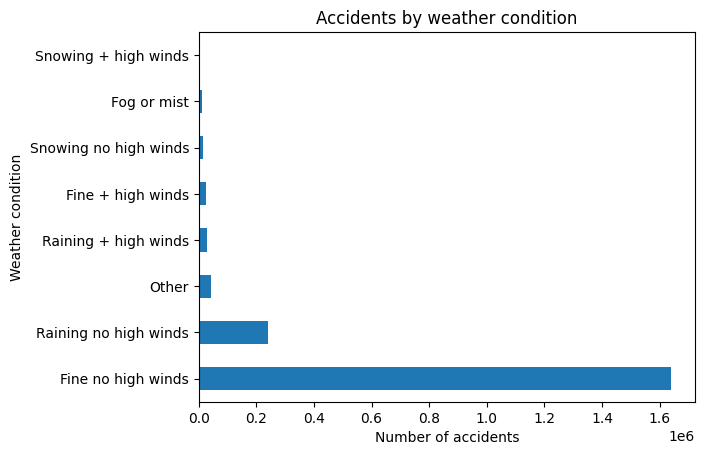

In [62]:
accidents['Weather_Conditions'].value_counts().plot(kind='barh')
plt.title('Accidents by weather condition')
plt.xlabel('Number of accidents')
plt.ylabel('Weather condition')
plt.show()


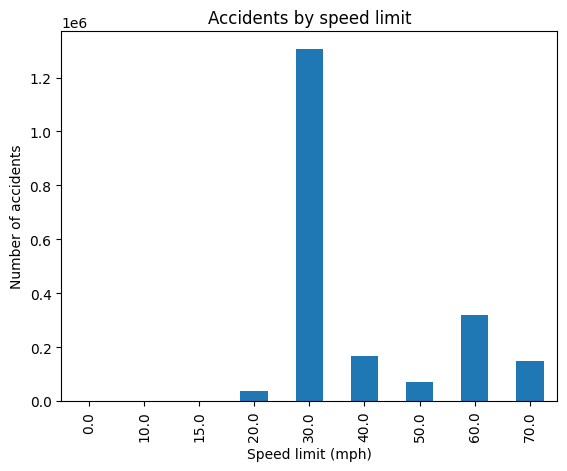

In [63]:
accidents['Speed_limit'].value_counts().sort_index().plot(kind='bar')
plt.title('Accidents by speed limit')
plt.xlabel('Speed limit (mph)')
plt.ylabel('Number of accidents')
plt.show()


### Finding 2: counts show where people drive, not what is dangerous

Both charts above show the same thing:

- 80% of accidents happened in fine weather with no high wind
- 64% of them were at a 30 mph speed limit

Looking at the weather chart it would be easy to say "fine weather is dangerous". But that is
backwards. Most driving in the UK happens in fine weather on ordinary 30 mph roads — so most
crashes happen there too, simply because there are far more chances for something to go wrong.

**This is the idea the rest of the notebook is built on.** Counting accidents only tells me
where people drive. To find what is actually dangerous I need the *percentage* of accidents in
each group that were fatal, which is what Section 10 does.

---
## Section 3 — Fatal Accidents by year

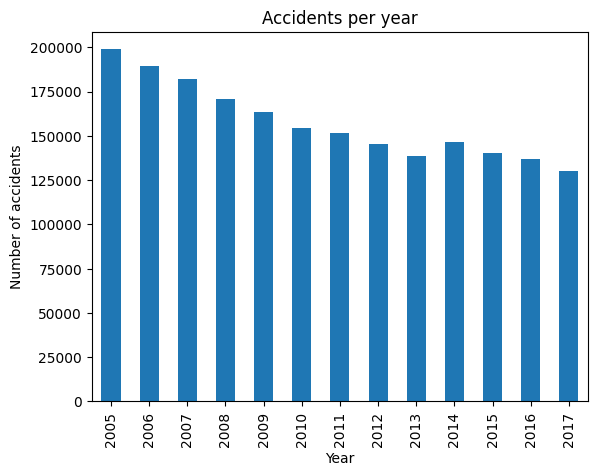

In [64]:
accidents['Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Accidents per year')
plt.xlabel('Year')
plt.ylabel('Number of accidents')
plt.show()


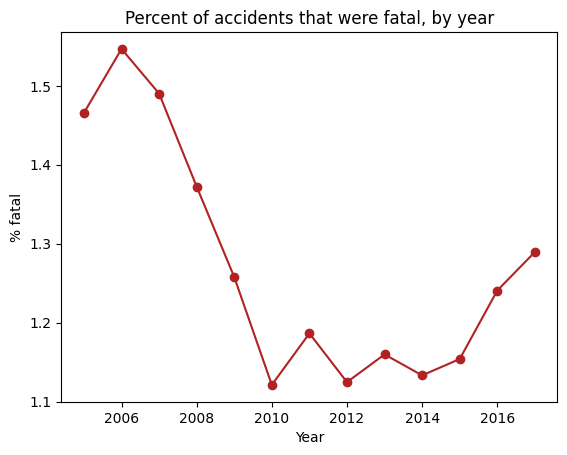

In [65]:
year_severity = accidents.groupby('Year')['Accident_Severity'].value_counts(normalize=True).unstack()
fatal_by_year = year_severity['Fatal'] * 100

fatal_by_year.plot(kind='line', marker='o', color='firebrick')
plt.title('Percent of accidents that were fatal, by year')
plt.xlabel('Year')
plt.ylabel('% fatal')
plt.show()


### Finding 3: accidents fell by a third, but the fatal share stopped improving in 2010

The count chart falls steadily and hard. 2005 had 198,735 accidents and 2017 had 129,982 — a
**34.6% drop** across thirteen years. The only year that goes up at all is 2014.

The second chart is the one I did not expect. The fatal percentage nudges up to a peak of 1.55%
in 2006, then falls steeply for four years to **1.12% in 2010** — and there it stops, drifts
sideways, and climbs back to 1.29% by 2017. Nearly 40% of the improvement has been given
back.

Putting the two together is what makes it interesting. Accidents kept falling after 2010, but
the *fatal* count flattened out — 1,731 in 2010 against 1,676 in 2017, essentially unchanged
while total accidents fell by another 15%. So whatever drove the improvement up to 2010 was
taking crashes off the road across the board, and since then the ordinary crashes have carried
on falling while the deadly ones have not.

I can't tell from this data why. It could be genuinely worse outcomes, or it could be a
reporting change — if minor slight-injury crashes became less likely to be reported over time,
the fatal share would rise on its own without anything actually getting worse. Both would look
exactly like this chart.

The practical point for us is that **year is not a neutral column**. If we train on all
thirteen years pooled together, the model learns an average fatal rate that was never true in
any particular year, and it learns it mostly from the older years, which are the biggest. I'd
want us to decide deliberately whether `Year` goes into the model as a feature, and whether
the older years should be down-weighted or dropped.


---
## Section 4 — Accidents by driver age band

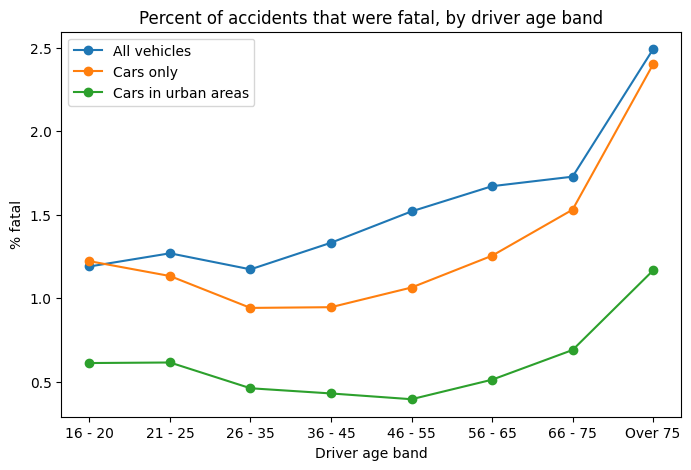

In [66]:
# Urban_or_Rural_Area is in the accident file, so bring it across with severity
age_data = vehicles.merge(
    accidents[['Accident_Index', 'Accident_Severity', 'Urban_or_Rural_Area']],
    on='Accident_Index', how='inner')

# the 0-5, 6-10 and 11-15 bands are tiny and almost certainly cyclists, so leave them out
band_order = ['16 - 20', '21 - 25', '26 - 35', '36 - 45', '46 - 55', '56 - 65', '66 - 75', 'Over 75']

def fatal_by_band(df):
    counts = df.groupby('Age_Band_of_Driver')['Accident_Severity'].value_counts(normalize=True)
    return (counts.unstack()['Fatal'] * 100).reindex(band_order)

cars_only = age_data[age_data['Vehicle_Type'] == 'Car']
urban_cars = cars_only[cars_only['Urban_or_Rural_Area'] == 'Urban']

age_severity = pd.DataFrame({
    'All vehicles': fatal_by_band(age_data),
    'Cars only': fatal_by_band(cars_only),
    'Cars in urban areas': fatal_by_band(urban_cars),
})

age_severity.plot(kind='line', marker='o', figsize=(8, 5))
plt.title('Percent of accidents that were fatal, by driver age band')
plt.xlabel('Driver age band')
plt.ylabel('% fatal')
plt.show()


### Finding 4: driver age is a U-shape, and the old end is much steeper than the young end

The line is not flat and it is not a straight climb. It **dips in the middle and rises at both
ends**, and the two ends are nowhere near equal.

Taking all vehicles: the safest drivers are 26–35 at 1.17% fatal. From there it climbs steadily
through 46–55 (1.52%), 66–75 (1.73%) and then jumps to **2.49% for Over 75** — nearly double the
1.33% average across the whole file. The young end rises too, but far more gently: 16–20 sits at
1.19%, barely above the 26–35 trough.

That surprised me. Young drivers are the group everyone worries about, and they do appear in a
lot of accidents — 165,772 of them. But when one happens, it is the **oldest** drivers whose
crashes are most likely to be fatal.

**The pattern is not an artefact of what people drive or where.** That is why the chart has three
lines rather than one:

- **Cars only** removes the motorcycles. 16–20 year olds are 10% motorcyclists and Over 75s are
  96% car drivers, so this mattered. The U gets *deeper*: 0.94% at 26–35 against 2.40% Over 75.
- **Cars in urban areas** removes the fast rural roads from Findings 5 and 6. Everything drops,
  but the shape holds: 0.40% at 46–55 against 1.17% Over 75.

The ratio between the trough and the Over 75 group is 2.6x for all cars and 2.9x for urban cars
only. Controlling for the two things I thought would explain it leaves it essentially untouched.
Rural driving in particular can be ruled out — 16–20 year olds do the *highest* share of their
car driving on rural roads (45.4%), slightly more than the Over 75s (44.7%), and they are still
the safer group.

**The most likely explanation is fragility rather than driving.** An 80-year-old and a 30-year-old
in the same collision do not face the same odds of surviving it. That would raise the fatal rate
for older drivers without them being any worse at driving. I cannot confirm this from the data,
because `Accident_Severity` describes the *accident*, not a person — I have no way to tell whether
the older driver was the one who died or whether it was someone else. That is the single biggest
caveat on this finding.

For the model, `Age_Band_of_Driver` looks worth including: the effect is large, it survives both
controls, and it is monotonic across the top five bands rather than noisy. Two cautions. The band
is missing for 7.9% of rows. And I dropped the 0–5, 6–10 and 11–15 bands from the chart because
they hold 4,566 rows between them and are almost certainly the cyclists from the open question
below.


---

## Sections 5–8 — Oluwafikunayomi Adeniji's Findings

My analysis focused on accident severity and the conditions that seemed to be associated with more serious outcomes. I looked at the overall distribution of severity first, then compared severity across speed limits, lighting conditions, and urban versus rural areas.

In [67]:
# This cell can be deleted — `accidents` is already loaded at the top of the notebook
# (the cell that reads from data/preprocessed/), so Sections 5-8 run on it as-is.
#
# Two reasons to delete rather than fix the path: data/archive/ isn't in the repo, so this
# errors out for everyone else; and re-loading here reassigns `accidents` to the raw file,
# which silently changes what Sections 1-4 mean if anyone re-runs them afterward.
#
# Worth re-running your sections after — the cleaned data has the 'Data missing or out of
# range' values converted to NaN, so they drop out of your crosstabs and a few percentages
# may shift. See data/README.md for the path convention.

#accidents = pd.read_csv(
 #   "../data/archive/Accident_Information.csv",
#    low_memory=False
#)

# accidents.shape

## Section 5 — Accident Severity Distribution

Before looking at what factors might be associated with severe accidents, I wanted to understand how the severity levels were distributed across the dataset. This is especially important because accident severity is a potential target for the supervised modeling stage of the project.

Accident_Severity
Slight     1734548
Serious     286339
Fatal        26369
Name: count, dtype: int64

Accident_Severity
Slight     84.73
Serious    13.99
Fatal       1.29
Name: proportion, dtype: float64


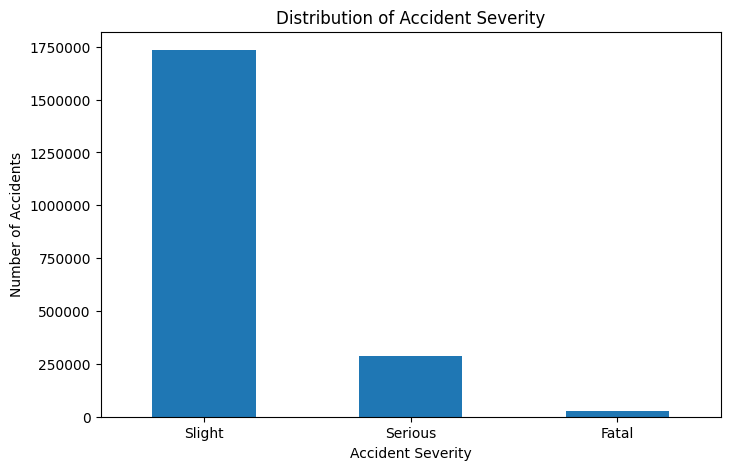

In [68]:
severity_counts = accidents["Accident_Severity"].value_counts()
severity_percent = accidents["Accident_Severity"].value_counts(normalize=True) * 100

print(severity_counts)
print()
print(severity_percent.round(2))

severity_counts.reindex(["Slight", "Serious", "Fatal"]).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")
plt.show()

### What I Found

The severity distribution is heavily imbalanced. About **84.73% of accidents were slight**, compared with **13.99% serious** and only **1.29% fatal**. This stood out because a model could achieve high overall accuracy simply by predicting the majority class most of the time. Because of this imbalance, accuracy alone may not be enough when we evaluate our classification models later. Metrics such as recall, F1-score, and the confusion matrix will also be important, especially for serious and fatal accidents.

## Section 6 — Speed Limit and Accident Severity

After seeing how imbalanced accident severity was, I wanted to look at whether speed limit was associated with more severe outcomes. Rather than comparing only the number of accidents at each speed limit, I compared the percentage of accidents that were slight, serious, or fatal within each speed-limit group.

Accident_Severity,Slight,Serious,Fatal
Speed_limit,,,
20.0,84.81,14.66,0.52
30.0,86.56,12.77,0.67
40.0,84.43,14.10,1.47
50.0,82.49,15.30,2.21
60.0,77.54,19.30,3.15
70.0,85.27,12.41,2.32


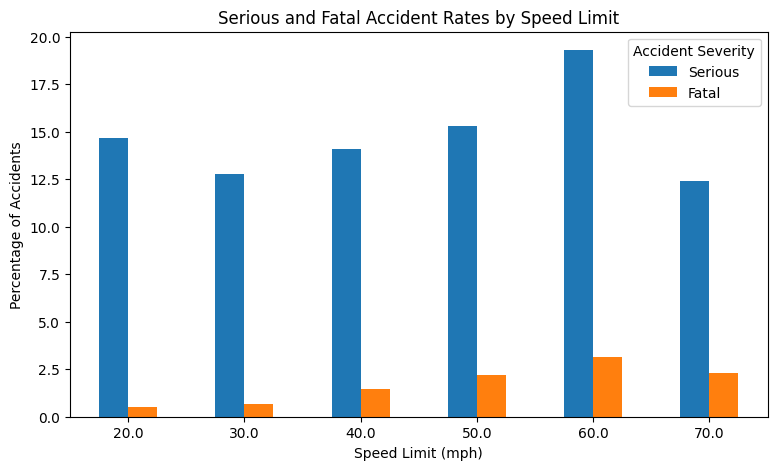

In [69]:
common_speed_limits = [20, 30, 40, 50, 60, 70]

speed_data = accidents[
    accidents["Speed_limit"].isin(common_speed_limits)
]

speed_severity = pd.crosstab(
    speed_data["Speed_limit"],
    speed_data["Accident_Severity"],
    normalize="index"
) * 100

speed_severity = speed_severity[
    ["Slight", "Serious", "Fatal"]
]

display(speed_severity.round(2))

speed_severity[["Serious", "Fatal"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Serious and Fatal Accident Rates by Speed Limit")
plt.xlabel("Speed Limit (mph)")
plt.ylabel("Percentage of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Accident Severity")
plt.show()

### What I Found

Accident severity generally increased as the speed limit increased from **30 mph to 60 mph**. Roads with a **60 mph speed limit had the highest proportion of serious accidents (19.3%) and fatal accidents (3.15%)**. However, the pattern was not perfectly linear, since the percentages decreased at 70 mph. This suggests that speed limit is associated with accident severity, but other factors such as road type, traffic conditions, and location may also play an important role.

## Section 7 — Light Conditions and Accident Severity

I also wanted to see whether visibility and lighting conditions were associated with accident severity. Since daylight accidents are much more common overall, I compared the percentage of slight, serious, and fatal accidents within each lighting condition rather than using the raw number of accidents.

Accident_Severity,Slight,Serious,Fatal
Light_Conditions,,,
Darkness - lighting unknown,85.38,13.35,1.27
Darkness - lights lit,83.44,15.22,1.35
Darkness - lights unlit,82.37,15.73,1.91
Darkness - no lighting,75.73,19.88,4.39
Daylight,85.76,13.21,1.03


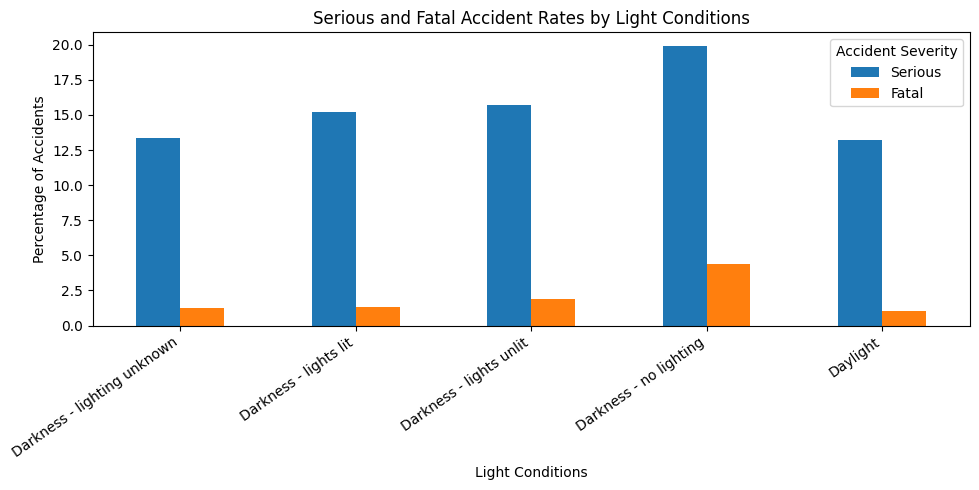

In [70]:
light_severity = pd.crosstab(
    accidents["Light_Conditions"],
    accidents["Accident_Severity"],
    normalize="index"
) * 100

light_severity = light_severity[
    ["Slight", "Serious", "Fatal"]
]

display(light_severity.round(2))

light_severity[["Serious", "Fatal"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Serious and Fatal Accident Rates by Light Conditions")
plt.xlabel("Light Conditions")
plt.ylabel("Percentage of Accidents")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Accident Severity")
plt.tight_layout()
plt.show()

### What I Found

Accidents that occurred in **darkness with no lighting** had the highest severity among the actual lighting conditions, with **19.88% classified as serious and 4.39% as fatal**. In comparison, daylight accidents were **13.21% serious and 1.03% fatal**. The fatal rate under no lighting was more than four times the daylight rate. This suggests that lighting conditions may be an important predictor of accident severity and could be useful during the modeling stage.

## Section 8 — Urban vs. Rural Accident Severity

Urban areas had more accidents overall, but I wanted to know whether the severity of those accidents differed from accidents in rural areas. To make the comparison fair, I looked at the percentage of slight, serious, and fatal accidents within each area type rather than comparing raw accident counts.

Accident_Severity,Slight,Serious,Fatal
Urban_or_Rural_Area,,,
Rural,81.15,16.50,2.35
Urban,86.69,12.61,0.71


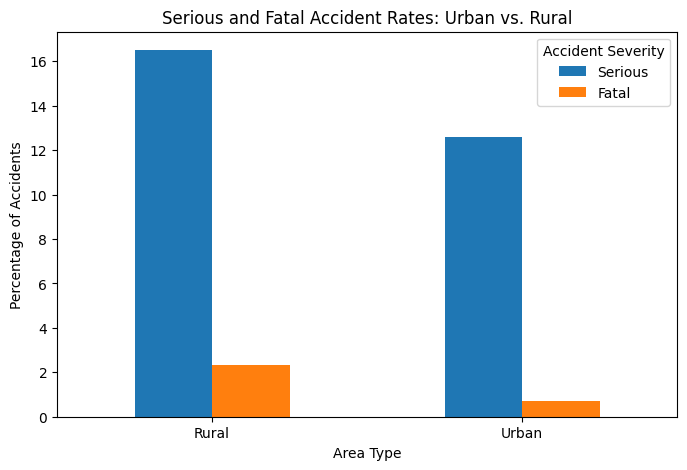

In [71]:
urban_rural_data = accidents[
    accidents["Urban_or_Rural_Area"].isin(["Urban", "Rural"])
]

urban_rural_severity = pd.crosstab(
    urban_rural_data["Urban_or_Rural_Area"],
    urban_rural_data["Accident_Severity"],
    normalize="index"
) * 100

urban_rural_severity = urban_rural_severity[
    ["Slight", "Serious", "Fatal"]
]

display(urban_rural_severity.round(2))

urban_rural_severity[["Serious", "Fatal"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Serious and Fatal Accident Rates: Urban vs. Rural")
plt.xlabel("Area Type")
plt.ylabel("Percentage of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Accident Severity")
plt.show()

### What I Found

Although urban areas had more accidents overall, rural accidents were more severe. About **16.50% of rural accidents were serious and 2.35% were fatal**, compared with **12.61% serious and 0.71% fatal in urban areas**. The fatal accident rate was more than three times higher in rural areas. This suggests that whether an accident occurs in an urban or rural area could be an important feature when predicting accident severity. 